In [1]:
%load_ext autoreload
%autoreload 2

import os
from PIL import Image, ImageOps
import requests
import torch
import matplotlib.pyplot as plt
import numpy as np

import torch
import requests
from tqdm import tqdm
from io import BytesIO
from diffusers import StableDiffusionInpaintPipeline
import torchvision.transforms as T

from utils import preprocess, prepare_mask_and_masked_image, recover_image

In [2]:
to_pil = T.ToPILImage()

In [3]:
""" tested with
orch        2.8.0+cu128
diffusers    0.35.1
np           2.2.4
"""
import diffusers
for k,v in dict(torch=torch, diffusers=diffusers, np=np).items():
    print(f"{k:<12} {v.__version__}")

torch        2.8.0+cu128
diffusers    0.35.1
np           2.2.4


In [4]:
# minor change to use desired device instead of assuming cuda:0
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"[{i}] {torch.cuda.get_device_name(i)}")
# torch.set_default_device("cuda:1") # does not exist in torch 1.12.1
# device = torch.device("cuda:1") # use named de
device = torch.device("cuda:1")

[0] NVIDIA TITAN RTX
[1] NVIDIA RTX A6000


### First lets instantiate an inpainting stable diffusion model

In [5]:
# make sure you're logged in with `huggingface-cli login` - check https://github.com/huggingface/diffusers for more details
# since runwayml has yanked its models, <"runwayml/stable-diffusion-inpainting"> lets use a different inpainting model
# eg. stable-diffusion-v1-5/stable-diffusion-inpainting"
# tested with stabilityai/stable-diffusion-2-inpainting, with weird results
modelid = "stable-diffusion-v1-5/stable-diffusion-inpainting"
# no     revision="fp16", 
pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    modelid,
    torch_dtype=torch.float16,
)
pipe_inpaint = pipe_inpaint.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/weights/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/weights/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
`torch_dtype` is deprecated! Use `dtype` instead!
An error occurred while trying to fetch /home/weights/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/weights/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_p

### The image to immunize
Now let's load image + some mask so that we can inpaint the rest!

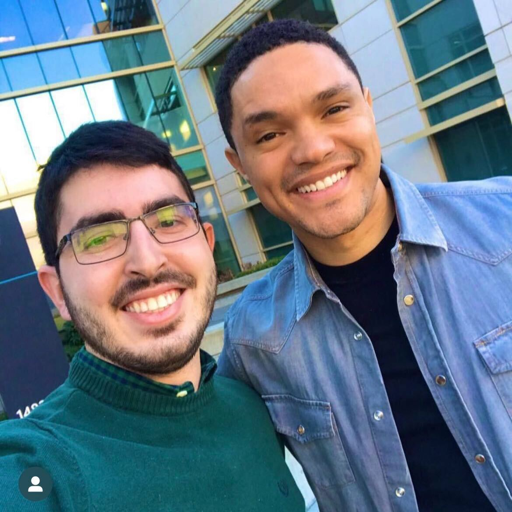

In [6]:
init_image = Image.open(f'../assets/trevor_5.jpg').convert('RGB').resize((512,512))
mask_image = Image.open(f'../assets/trevor_5.tif').convert('RGB')
mask_image = ImageOps.invert(mask_image).resize((512,512))
init_image

### Simple attack implementation
Now we implement a simple PGD attack 

In [7]:
def pgd(X, target, model, criterion, eps=0.1, step_size=0.015, iters=40, clamp_min=0, clamp_max=1, mask=None, device="cuda"):
    X_adv = X.clone().detach() + (torch.rand(*X.shape)*2*eps-eps).to(device)
    pbar = tqdm(range(iters))
    for i in pbar:
        actual_step_size = step_size - (step_size - step_size / 100) / iters * i  
        X_adv.requires_grad_(True)                    

        loss = (model(X_adv).latent_dist.mean - target).norm()

        pbar.set_description(f"[Running attack]: Loss {loss.item():.5f} | step size: {actual_step_size:.4}")

        grad, = torch.autograd.grad(loss, [X_adv])
        
        X_adv = X_adv - grad.detach().sign() * actual_step_size
        X_adv = torch.minimum(torch.maximum(X_adv, X - eps), X + eps)
        X_adv.data = torch.clamp(X_adv, min=clamp_min, max=clamp_max)
        X_adv.grad = None    
        
        if mask is not None:
            X_adv.data *= mask
            
    return X_adv

### Target image
Here, different from the img2img notebook, we will attack the image towards the embedding of some random target image from the internet!

You can still effectively attack towards an embedding of zeros too! 

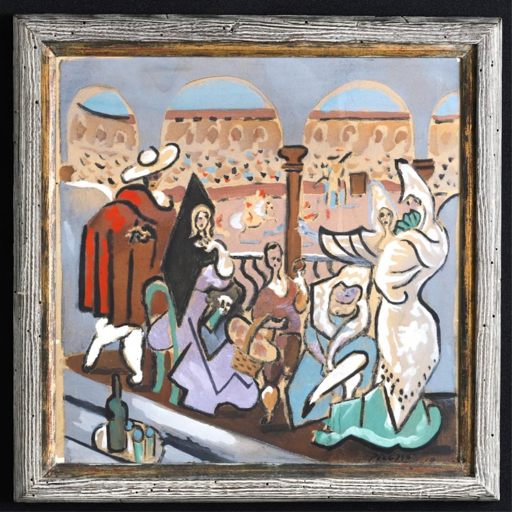

In [8]:
target_url = "https://bostonglobe-prod.cdn.arcpublishing.com/resizer/2-ZvyQ3aRNl_VNo7ja51BM5-Kpk=/960x0/cloudfront-us-east-1.images.arcpublishing.com/bostonglobe/CZOXE32LQQX5UNAB42AOA3SUY4.jpg"

response = requests.get(target_url)
target_image = Image.open(BytesIO(response.content)).convert("RGB")
target_image = target_image.resize((512, 512))
target_image



### Executing the attack
Now we apply the attack to our image

In [9]:


with torch.autocast('cuda'):
    mask, X = prepare_mask_and_masked_image(init_image, mask_image)
    X = X.half().to(device)
    mask = mask.half().to(device)
    
    # Here we attack towards the embedding of a random target image. You can also simply attack towards an embedding of zeros!
    target = pipe_inpaint.vae.encode(preprocess(target_image).half().to(device)).latent_dist.mean

    adv_X = pgd(X, 
                target = target,
                model=pipe_inpaint.vae.encode, 
                criterion=torch.nn.MSELoss(), 
                clamp_min=-1, 
                clamp_max=1,
                eps=0.06, 
                step_size=0.01, 
                iters=1000,
                mask=1-mask,
                device=device
               )

    adv_X = (adv_X / 2 + 0.5).clamp(0, 1)

[Running attack]: Loss 598.98444 | step size: 0.0001099: 100%|███████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:30<00:00, 11.07it/s]


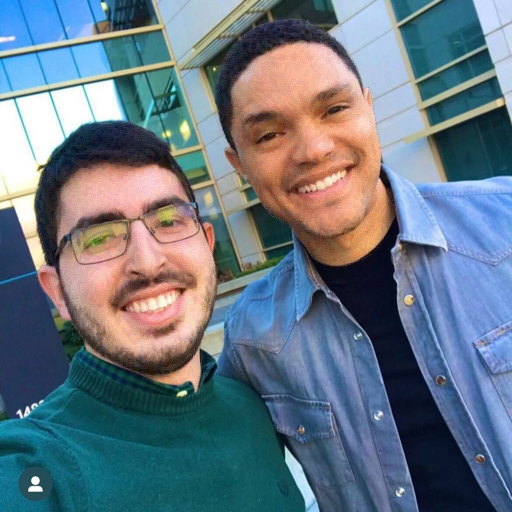

In [10]:
adv_image = to_pil(adv_X[0]).convert("RGB")
adv_image = recover_image(adv_image, init_image, mask_image, background=True)
adv_image

### Running Stable Diffusion Inpainting
Now that we generated an "immunized"/adversarial image, lets try to run inpainting using stable diffusion on both the original and the adversarial images
* changed changed 'in the' to 'on a'
* removed strength parameter invalid it pipe_inpaint

In [11]:
# prompt = "man riding a motorcycle at night"
# prompt = "two men in a wedding"
# prompt = "two men in a restaurant hugging"
# prompt = "two men in a classroom"
# prompt = "two men in a library"
prompt = "two men on a plane hugging" # changed 'in the' to 'on a'


# A good seed
SEED = 9209

# Uncomment the below to generated other images
# SEED = np.random.randint(low=0, high=100000)

torch.manual_seed(SEED)
print(SEED)

strength = 0.7
guidance_scale = 7.5
num_inference_steps = 100

image_nat = pipe_inpaint(prompt=prompt, 
                     image=init_image, 
                     mask_image=mask_image, 
                     eta=1,
                     num_inference_steps=num_inference_steps,
                     guidance_scale=guidance_scale,
                     # strength=strength
                    ).images[0]
image_nat = recover_image(image_nat, init_image, mask_image)

torch.manual_seed(SEED)
image_adv = pipe_inpaint(prompt=prompt, 
                     image=adv_image, 
                     mask_image=mask_image, 
                     eta=1,
                     num_inference_steps=num_inference_steps,
                     guidance_scale=guidance_scale,
                     # strength=strength
                    ).images[0]
image_adv = recover_image(image_adv, init_image, mask_image)

9209


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

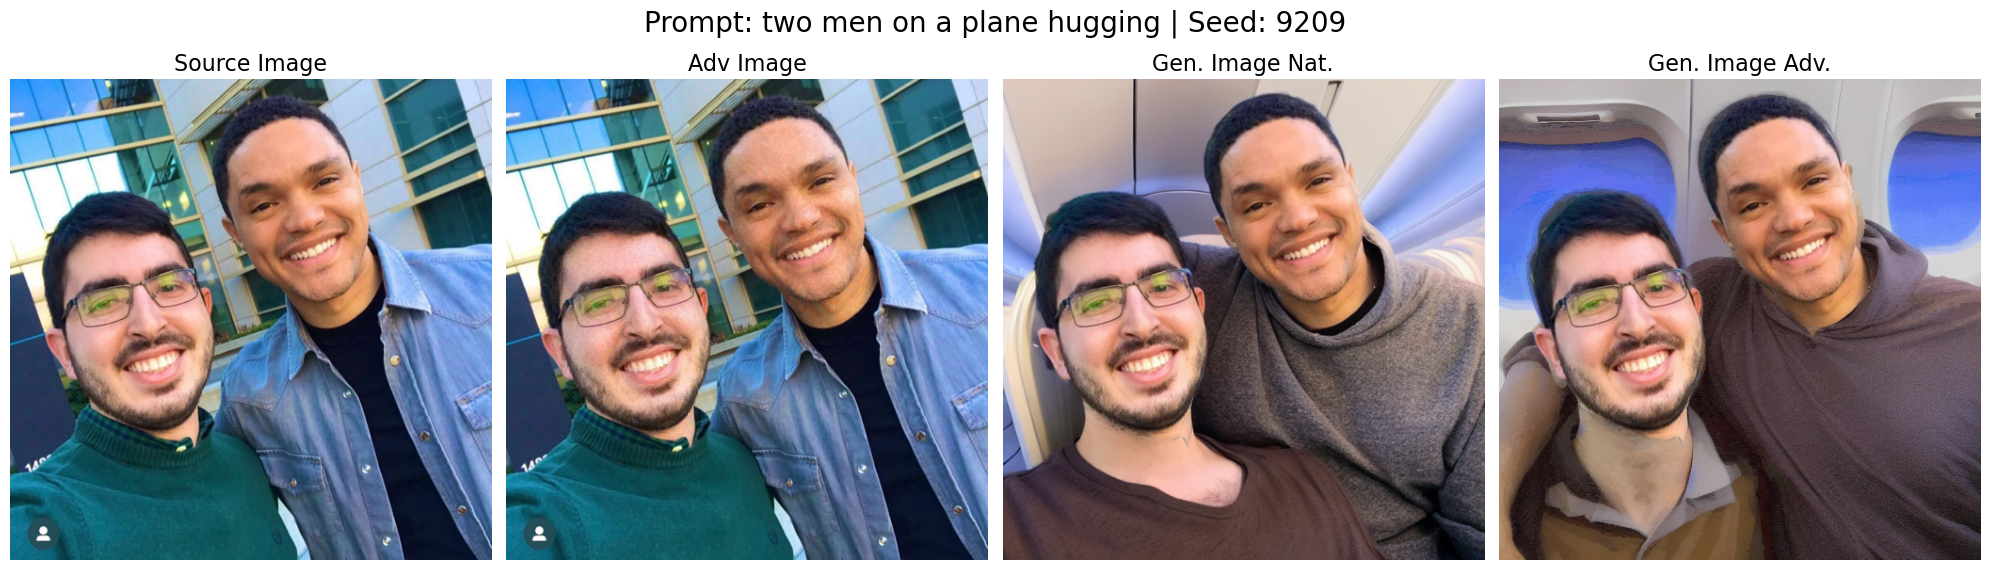

In [12]:
adv_image = recover_image(adv_image, init_image, mask_image, background=True)
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20,6))

ax[0].imshow(init_image)
ax[1].imshow(adv_image)
ax[2].imshow(image_nat)
ax[3].imshow(image_adv)

ax[0].set_title('Source Image', fontsize=16)
ax[1].set_title('Adv Image', fontsize=16)
ax[2].set_title('Gen. Image Nat.', fontsize=16)
ax[3].set_title('Gen. Image Adv.', fontsize=16)

for i in range(4):
    ax[i].grid(False)
    ax[i].axis('off')
    
fig.suptitle(f"Prompt: {prompt} | Seed: {SEED}", fontsize=20)
fig.tight_layout()
plt.show()

### Notice how the image generated from the adversarial example is not realistic! For a much stronger attack check `demo_complex_attack_inpainting.ipynb` and compare the results!